In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
pd.set_option('display.max_columns', None)

## Ex07
- Анализируй только пользователей (не учитывай админов).
- Для обоих графиков выбери понравившуюся палитру.
- Для запроса используй таблицу checker.
- Используй абсолютные числа коммитов (не средние).
- Отсортируй DataFrame по общему числу коммитов пользователя.
- В конце блокнота добавь markdown-ячейку и ответь (смотри только на графики):
    - «У какого пользователя больше всего коммитов во Вт?» Ответ: user_*.
    - «У какого пользователя больше всего коммитов в Чт?» Ответ: user_*.
    - «В какой день недели пользователи не любят много коммитить?» Ответ, например: Monday.
    - «Какой пользователь и в который час сделал наибольшее число коммитов?» Ответ, например: user_1, 15.

Сделай всё необходимое, чтобы получить два графика как на примере.

In [3]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

In [4]:
commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    """,
    conn,
    parse_dates=["timestamp"]
)

acronyms = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

commits['hour'] = commits['timestamp'].dt.hour
commits['day'] = commits['timestamp'].dt.dayofweek
commits['acronym_day'] = commits['day'].map(acronyms)

commits

,uid,timestamp,hour,day,acronym_day
0,user_4,2020-04-17 05:19:02.744528,5,4,Fri
1,user_4,2020-04-17 05:22:35.249331,5,4,Fri
2,user_4,2020-04-17 05:22:45.549397,5,4,Fri
3,user_4,2020-04-17 05:34:14.691200,5,4,Fri
4,user_4,2020-04-17 05:34:24.422370,5,4,Fri
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,20,3,Thu
3203,user_1,2020-05-21 20:22:41.785725,20,3,Thu
3204,user_1,2020-05-21 20:22:41.877806,20,3,Thu
3205,user_1,2020-05-21 20:37:00.129678,20,3,Thu


In [5]:
user_order = commits['uid'].value_counts().index.tolist()
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot_day = pd.crosstab(commits['acronym_day'], commits['uid'])
pivot_day = pivot_day.reindex(index=day_order, columns=user_order, fill_value=0)

pivot_day

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,user_29,user_13,user_28,user_24,user_12,user_8,user_1,user_21,user_30,user_18,user_17,user_16,user_27,user_15,user_6,user_22,user_11,user_7,user_23,user_0
acronym_day,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Mon,35,50,24,14,7,0,23,5,0,46,9,3,0,0,2,0,0,0,2,13,8,10,0,0,1,2,0,0,0,3
Tue,86,87,131,44,9,1,0,0,16,11,26,57,7,14,1,0,0,16,3,0,4,5,0,0,0,3,0,5,0,0
Wed,33,0,32,15,0,34,8,0,37,0,32,0,44,18,0,0,1,21,1,2,1,0,0,0,4,0,0,3,0,0
Thu,108,17,4,40,78,51,96,7,77,7,25,4,12,54,7,15,39,4,20,46,17,14,15,5,2,2,0,0,6,0
Fri,61,0,0,10,10,2,7,35,1,59,1,0,7,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0
Sat,0,79,31,66,21,16,3,90,4,3,2,28,12,17,7,46,1,19,22,0,32,0,0,4,2,0,0,0,0,0
Sun,45,26,13,44,51,69,28,7,2,8,26,23,32,1,76,26,43,23,21,5,0,31,27,20,9,1,8,0,0,0


In [6]:
pivot_day.info()

<class 'pandas.DataFrame'>
Index: 7 entries, Mon to Sun
Data columns (total 30 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_4   7 non-null      int64
 1   user_14  7 non-null      int64
 2   user_2   7 non-null      int64
 3   user_25  7 non-null      int64
 4   user_19  7 non-null      int64
 5   user_26  7 non-null      int64
 6   user_20  7 non-null      int64
 7   user_31  7 non-null      int64
 8   user_10  7 non-null      int64
 9   user_3   7 non-null      int64
 10  user_29  7 non-null      int64
 11  user_13  7 non-null      int64
 12  user_28  7 non-null      int64
 13  user_24  7 non-null      int64
 14  user_12  7 non-null      int64
 15  user_8   7 non-null      int64
 16  user_1   7 non-null      int64
 17  user_21  7 non-null      int64
 18  user_30  7 non-null      int64
 19  user_18  7 non-null      int64
 20  user_17  7 non-null      int64
 21  user_16  7 non-null      int64
 22  user_27  7 non-null      int64
 23  user_1

In [7]:
pivot_hour = pd.crosstab(commits['hour'], commits['uid'])
pivot_hour = pivot_hour.reindex(index=range(24), columns=user_order, fill_value=0)

pivot_hour

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,user_29,user_13,user_28,user_24,user_12,user_8,user_1,user_21,user_30,user_18,user_17,user_16,user_27,user_15,user_6,user_22,user_11,user_7,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,4,0,0,0,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,13,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,3,6,0,0,10,2,0,3,0,0,20,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0
8,0,6,0,0,0,5,2,0,9,6,0,11,0,4,10,6,0,0,2,0,2,0,0,0,0,0,0,1,1,0


In [8]:
pivot_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 30 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_4   24 non-null     int64
 1   user_14  24 non-null     int64
 2   user_2   24 non-null     int64
 3   user_25  24 non-null     int64
 4   user_19  24 non-null     int64
 5   user_26  24 non-null     int64
 6   user_20  24 non-null     int64
 7   user_31  24 non-null     int64
 8   user_10  24 non-null     int64
 9   user_3   24 non-null     int64
 10  user_29  24 non-null     int64
 11  user_13  24 non-null     int64
 12  user_28  24 non-null     int64
 13  user_24  24 non-null     int64
 14  user_12  24 non-null     int64
 15  user_8   24 non-null     int64
 16  user_1   24 non-null     int64
 17  user_21  24 non-null     int64
 18  user_30  24 non-null     int64
 19  user_18  24 non-null     int64
 20  user_17  24 non-null     int64
 21  user_16  24 non-null     int64
 22  user_27  24 non-null     int64
 23  use

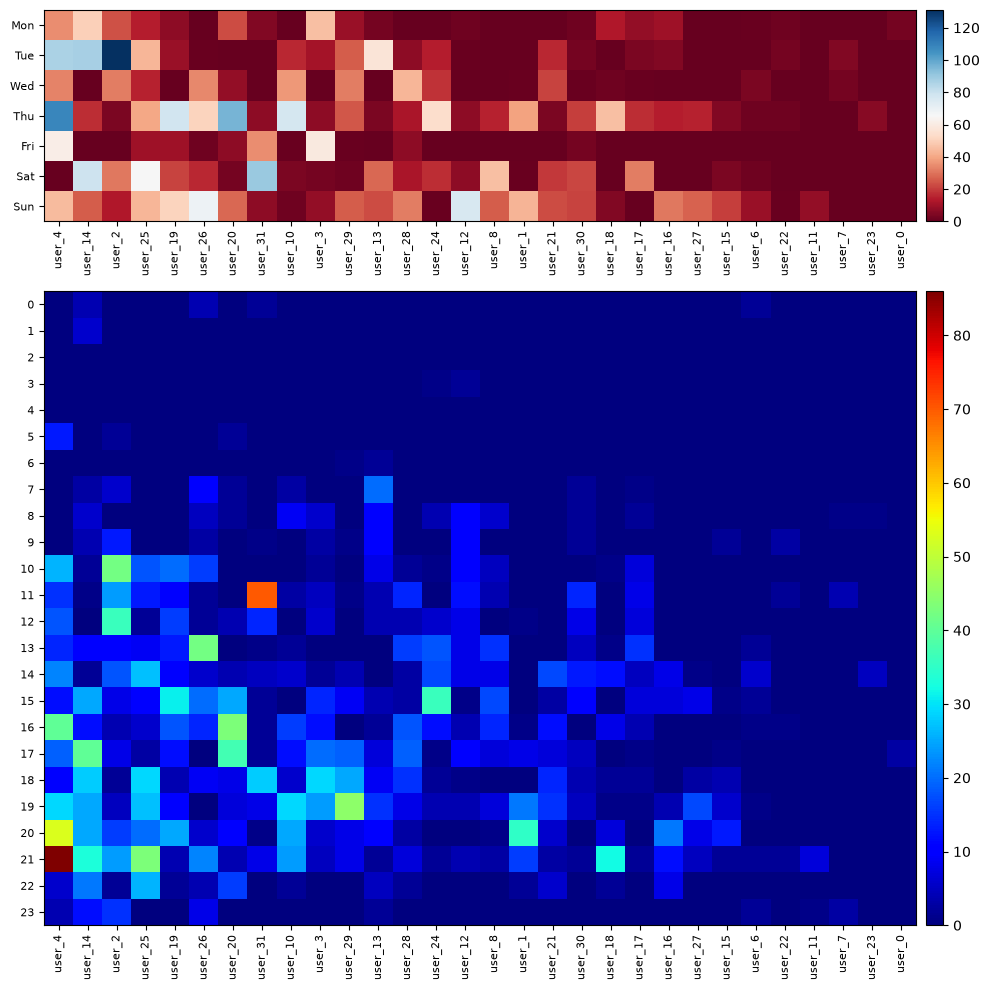

In [9]:
def plot_heatmap(ax, fig, data, yticks, yticklabels, cmap):
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.set_xticks(range(len(user_order)))
    ax.set_xticklabels(user_order, fontsize=8, rotation=90)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    fig.colorbar(im, cax=cax)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 3]})

plot_heatmap(ax1, fig, pivot_day.values, range(len(day_order)), day_order, 'RdBu')
plot_heatmap(ax2, fig, pivot_hour.values, range(24), range(24), 'jet')

plt.tight_layout()
plt.show()

- «У какого пользователя больше всего коммитов во Вт?»
    - **user_2**
- «У какого пользователя больше всего коммитов в Чт?»
    - **user_4**
- «В какой день недели пользователи не любят много коммитить?»
    - **Friday**
- «Какой пользователь и в который час сделал наибольшее число коммитов?»
    - **user_4, 21**

In [10]:
tue_top_user = pivot_day.loc['Tue'].idxmax()

thu_top_user = pivot_day.loc['Thu'].idxmax()

least_active_day = pivot_day.sum(axis=1).idxmin()

max_position = pivot_hour.stack().idxmax()
max_hour, max_user = max_position

In [11]:
print(f'У какого пользователя больше всего коммитов во Вт: {tue_top_user}')
print(f'У какого пользователя больше всего коммитов в Чт: {thu_top_user}')
print(f'В какой день недели пользователи не любят много коммитить: {least_active_day}')
print(f'Какой пользователь и в который час сделал наибольшее число коммитов: {max_user}, {max_hour}')

У какого пользователя больше всего коммитов во Вт: user_2
У какого пользователя больше всего коммитов в Чт: user_4
В какой день недели пользователи не любят много коммитить: Fri
Какой пользователь и в который час сделал наибольшее число коммитов: user_4, 21


In [12]:
conn.close()